# Математическая статистика для анализа больших данных
## Семинар 4.
### Робастные оценки

Выполненную работу нужно отправить телеграм-боту  `@stats_bd_bot`
* Дедлайн см. в телеграм-боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* По практическим задачам прислать нужно ноутбук в формате `ipynb`.
* Решения, размещенные на каких-либо интернет-ресурсах не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Не забывайте делать пояснения и выводы
* Решение теоретических задач можете записывать в markdown с помощью TeX, присылать в виде фотографий или вшивать в ноутбук через Insert Image (убеждайтесь, что картинка сохраняется при перемещении ноутбука в другое место)

In [ ]:
# Bot check

# HW_ID: sbd_sem4
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: not final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

In [1]:
from typing import Iterable

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.simplefilter("ignore", FutureWarning)

%matplotlib inline

__________________
### Airquality

Загрузим с помощью `pandas` из файла `airquality.csv` данные о качестве воздуха в Нью-Йорке с мая по сентябрь 1973 года по дням. Данные содержат измерения нескольких величин, описания которых можно прочитать [по ссылке](https://www.rdocumentation.org/packages/datasets/versions/3.5.1/topics/airquality).

In [ ]:
airquality = pd.read_csv("airquality.csv")
airquality.head(10)

,Ozone,Solar.R,Wind,Temp,Month,Day
0,41.0,190.0,7.4,67,5,1
1,36.0,118.0,8.0,72,5,2
2,12.0,149.0,12.6,74,5,3
3,18.0,313.0,11.5,62,5,4
4,NaN,NaN,14.3,56,5,5
5,28.0,NaN,14.9,66,5,6
6,23.0,299.0,8.6,65,5,7
7,19.0,99.0,13.8,59,5,8
8,8.0,19.0,20.1,61,5,9
9,NaN,194.0,8.6,69,5,10


In [ ]:
features = ["Ozone", "Solar.R", "Wind", "Temp"]

Выведем описательные статистики (метод `describe`) для всех признаков, для которых это имеет смысл.  

In [ ]:
airquality.drop(columns=["Month", "Day"]).describe().round(2)

,Ozone,Solar.R,Wind,Temp
count,116.00,146.00,153.00,153.00
mean,42.13,185.93,9.96,77.88
std,32.99,90.06,3.52,9.47
min,1.00,7.00,1.70,56.00
25%,18.00,115.75,7.40,72.00
50%,31.50,205.00,9.70,79.00
75%,63.25,258.75,11.50,85.00
max,168.00,334.00,20.70,97.00


Что можно сказать о наличии в данных выбросов, сравнивая выборочную медиану и выборочное среднее?

Видна ощутимая разница между средним и медианой у признаков `Ozone` (перекос в сторону больших значений) и `Solar.R` (в сторону малых значений). И то, и другое поддаётся объяснению: озона становится больше во время грозы, а солнечного света меньше из-за облачности. Для признаков `Wind` и `Temp` различие кажется не таким существенным.

**Замечание:** *Делать вывод о наличии выбросов только по разнице между медианой и средним, неправильно. Тем не менее, это хороший повод поставить и проверить гипотезу. Аппарат проверки гипотез в курсе будет рассказан позже.*

Для каждого параметра построим график ящиков с усами (`boxplot`), в котором ось `x` соответствует номеру месяца, а ось `y` — значениям параметра (т.е. свой ящик для каждого месяца)

In [ ]:
airquality.drop(columns="Day", inplace=True) # при дальнейшем анализе нам этот столбец не понадобится

In [ ]:
def plot_groupby(df, by: str, plotter=sns.boxplot):
    """
    Сгруппировать метрики по значению служебного столбца.
    Отобразить результаты в виде матрицы из картинок
    (по одной картинке на каждую метрику).

    @by
    — тип: строка
    — описание: название служебного столбца, по значениям
                которого формируются группы
    @plotter
    — тип: класс из seaborn или matplotlib
    — описание: тип графика
    """
    features = np.setdiff1d(df.columns, by)
    with sns.axes_style("whitegrid"):
        n_rows = np.ceil(len(features) / 2).astype(int)
        n_cols = 2

        fig, axes = plt.subplots(
            n_rows, n_cols,
            figsize=(14, 7 * n_rows)
        )
        for i, col in enumerate(features):
            ax = axes[i // 2, i % 2]
            plotter(
                x=by,
                y=col,
                data=df,
                ax=ax
            )
            ax.set_xlabel(by, weight="bold")
            ax.set_ylabel(col, weight="bold")

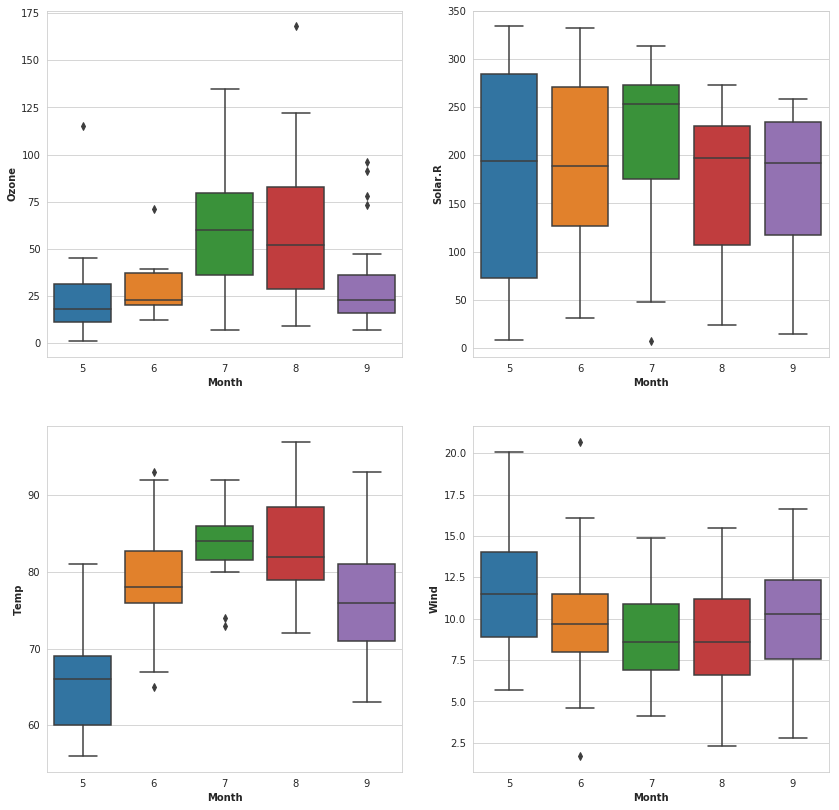

In [ ]:
plot_groupby(
    airquality,
    by="Month",
    plotter=sns.boxplot
)

Гипотеза о том, что больше всего выбросов в признакe Ozone подтверждается.

Построим аналогичные графики, используя `seaborn.violinplot`, популярную модификацию `boxplot`-а.  

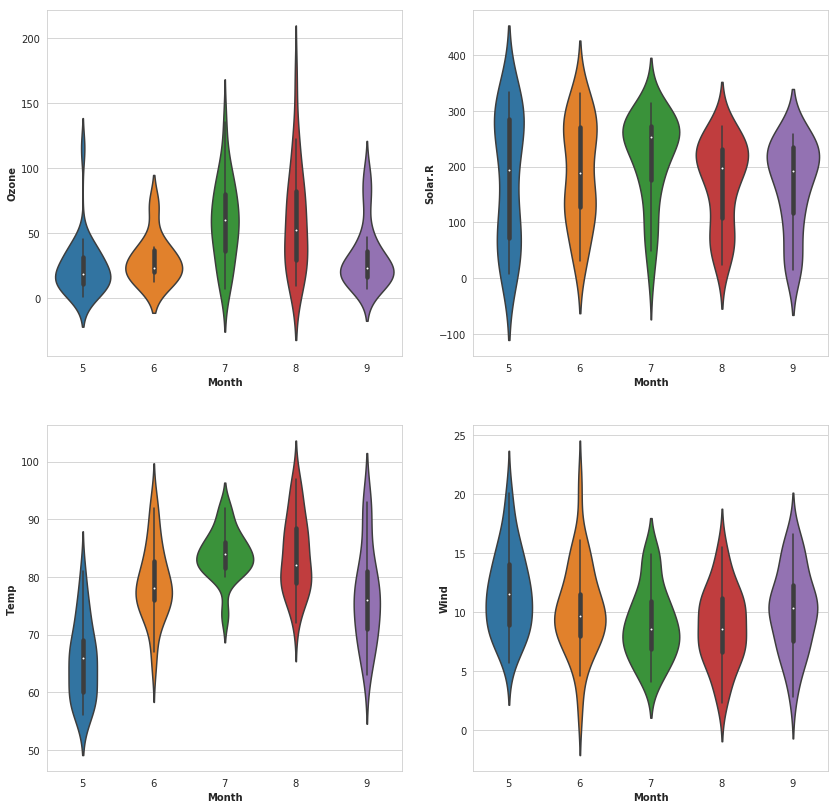

In [ ]:
plot_groupby(
    airquality,
    by="Month",
    plotter=sns.violinplot
)


- `violinplot` отрисовывает поверх `boxplot`-а ядерную оценку плотности (с двух сторон).
- По форме сразу можно понять, где сколько точек. Конкретно `seaborn`-овский `violinplot` имеет недостаток в том, что не изображает выбросы, но это особенности библиотеки.

---

# Задача 1 (самостоятельное решение)

В этой задаче мы исследуем, как реагируют на выбросы рассмотренные в курсе оценки: уcечённое среднее разных порядков и медиана средних Уолша. Мы реализуем функции для вычисления этих оценок и вычислим их асимптотические дисперсии в модели $\mathcal{N}(\theta, 1)$.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sps
import scipy
import seaborn as sns

import warnings
warnings.simplefilter("ignore", FutureWarning)

### Модель данных

Для того, чтобы смоделировать данные с выбросами, будем генерировать данные из стандартного нормального распределения $\mathcal{N}(0, 1)$, затем подмешивать в выборку заведомо плохие данные, которые при нормальном распределении получаются редко. Для этого некоторую долю сгенерированных значений заменим на данные из равномерного распределения $U(3, 4)$.

**Вопрос:** как вычислить вероятность попадания точки из нормального распределения в отрезок $[3, 4]$, если известны плотность $p$, функция распределения $F$, квантили $z_\alpha$?

In [ ]:
sps.norm.cdf(4) - sps.norm.cdf(3)

0.0013182267897969835

Напишем функцию для генерации выборки из данной модели с заданной долей выбросов

In [3]:
def generate_sample(size, alpha=0.1):
    """Генерирует данные из рассмотренной модели

    Принимает:
        size - размер выборки
        alpha - доля выбросов
    """
    # генерируем выборку и выбросы
    sample = sps.norm.rvs(size=size)
    n_outliers = int(np.floor(alpha * size))
    outliers = sps.uniform(loc=3, scale=1).rvs(size=n_outliers)

    # записываем в начало и перемешиваем
    sample[:n_outliers] = outliers
    np.random.shuffle(sample)
    return sample

Визуализирвем данные при 20 процентах выбросов

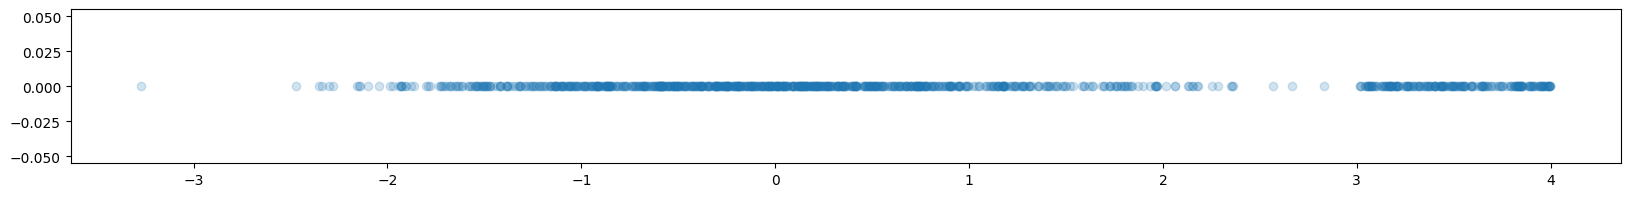

In [ ]:
sample = generate_sample(1000, alpha=0.2)
plt.figure(figsize=(20, 2))
plt.scatter(sample, np.zeros_like(sample), alpha=0.2)
plt.show()

Видим, что на отрезке $[3, 4]$ действительно больше элементов выборки, чем на отрезке $[-4, -3]$. В нашем случае по первому же графику явно видно, что модель с симметричным нормальным распределением не верна, но в многомерных данных отклонения могут быть не столь очевидны.

### Эмпирическая проверка на симметричность

Рассмотренные на лекции теоремы были верны только в случае симметричного распределения. Когда приходят данные, зачастую нет возможности сразу понять, симметричны ли они. Но можно проверить свойство: для любого симметричного распределения квантили уровня $p$ и $1 - p$ симметричны относительно медианы, то есть $u_{\frac{1}{2}} - u_p = u_{1 - p} - u_{\frac{1}{2}}$. Для порядковых статистик можно ожидать подобного свойства:

$$ \xi_i = \widehat{\mu} - Z_{(i)} \approx Z_{(n - i + 1)} - \widehat{\mu} = \eta_i$$

Приближённый критерий: точки $(\xi_i, \eta_i)$ расположены около прямой $y = x$

Напишем функцию построения точек $(\xi_i, \eta_i)$.

In [4]:
def check_symmetry_plot(sample):
    median = np.median(sample)
    sample = np.sort(sample)
    n_half = sample.size // 2

    # разделим массив на 2 половины
    fst_half = sample[:n_half]
    snd_half = sample[-n_half:][::-1]

    plt.scatter(median - fst_half, snd_half - median, alpha=0.2)

Cгенерируем выборки для проверки из нормального распределения и из нормального распределения с выбросами.

In [5]:
normal_sample = sps.norm.rvs(size=500)
shifted_sample = generate_sample(size=500, alpha=0.2)

Построим графики для проверки симметричности

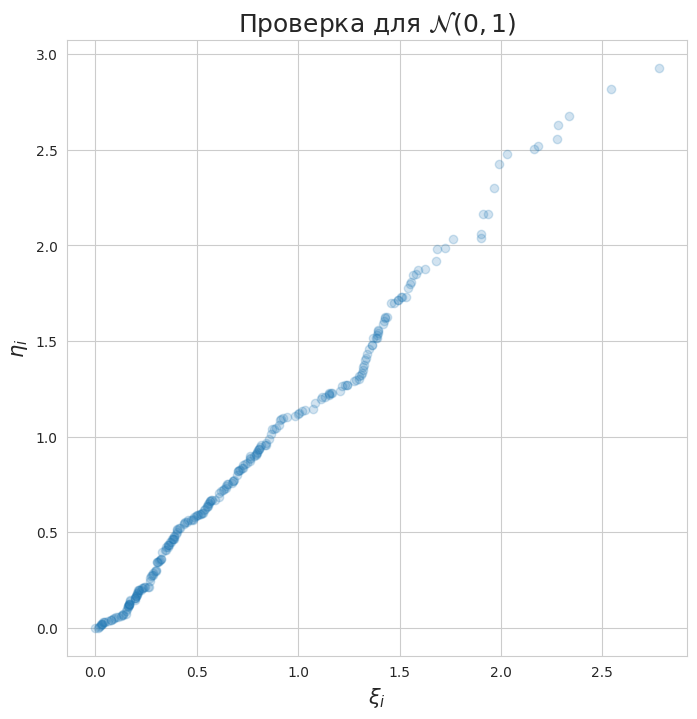

In [6]:
sns.set_style("whitegrid")
plt.figure(figsize=(8, 8))
plt.title("Проверка для $\mathcal{N}(0, 1)$", fontsize=18)
check_symmetry_plot(normal_sample)
plt.xlabel(r"$\xi_i$", fontsize=15)
plt.ylabel(r"$\eta_i$", fontsize=15)
plt.show()

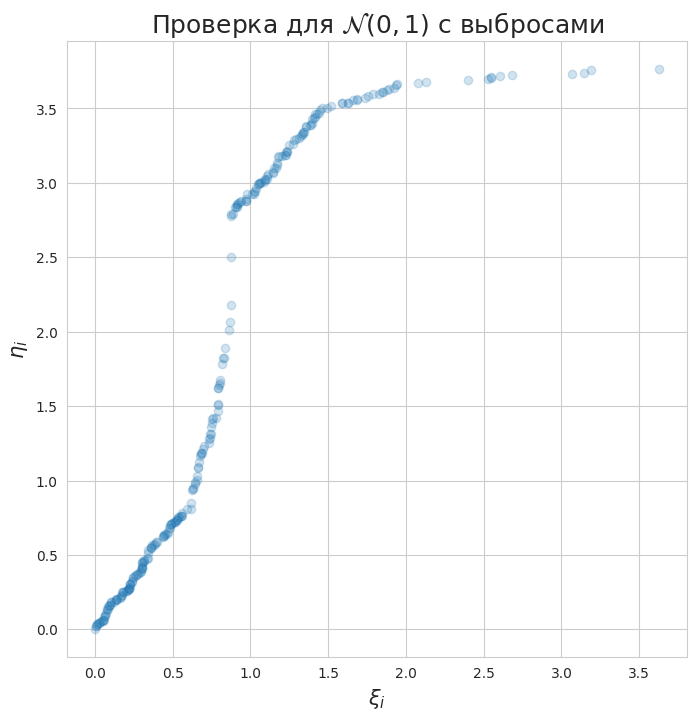

In [7]:
sns.set_style("whitegrid")
plt.figure(figsize=(8, 8))
plt.title("Проверка для $\mathcal{N}(0, 1)$ с выбросами", fontsize=18)
check_symmetry_plot(shifted_sample)
plt.xlabel(r"$\xi_i$", fontsize=15)
plt.ylabel(r"$\eta_i$", fontsize=15)
plt.show()

**Вывод:** Явно видно, что при распределении с выбросами точки начинают отклоняться от диангонали. При симметричном распределении отклонения совсем небольшие.

### Ящики с усами

Построим "ящики с усами", чтобы увидеть, смогут ли они помочь в определении выбросов при разном их количестве

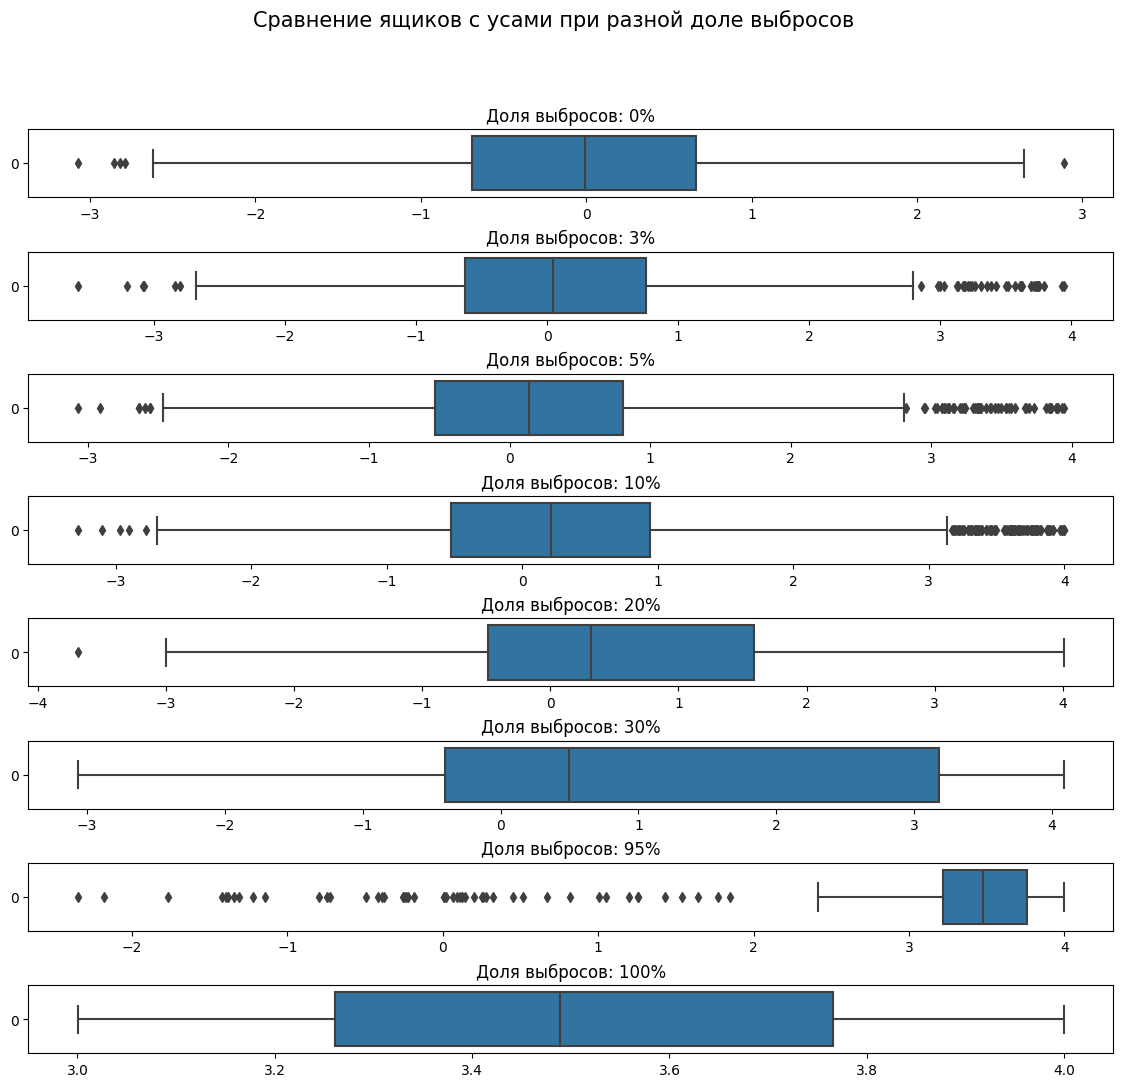

In [ ]:
sample_size = 1000
outlier_fractions = [0, 0.03, 0.05, 0.1, 0.2, 0.3, 0.95, 1]

_, axes = plt.subplots(
    len(outlier_fractions), 1,
    figsize=(14, 12)
)

for ax, alpha in zip(axes, outlier_fractions):
    sample = generate_sample(sample_size, alpha)
    sns.boxplot(sample, ax=ax, orient='h')
    ax.set_title('Доля выбросов: {:.0%}'.format(alpha))

plt.suptitle("Сравнение ящиков с усами при разной доле выбросов", fontsize=15)
plt.subplots_adjust(hspace=0.8) # больше расстояние по высоте

**Вывод:** На графике видно, что при доле выбросов от 0 до 10% (с допустимой погрешностью ±5%), ящики с усами четко демонстрируют наличие выбросов. Однако, когда доля выбросов достигает 15-30% (также с погрешностью ±5%), выбросы начинают включаться в усы графика, но все еще можно понять, с какой стороны находятся выбросы. При дальнейшем увеличении доли выбросов картина начинает искажаться, и становится сложно различить, что является выбросом, а что — нормальными данными.

### Реализация медианы средних Уолша

Чтобы посчитать медиану средних Уолша, надо взять все попарные средние $X_i$ и $X_j$, где $1 \leqslant i \leqslant j \leqslant n$, и вычислить медиану у полученных значений. Это можно сделать с двойным циклом, с одним циклом и без циклов совсем.

Сравним 3 способа по скорости. В качестве теста будем вычислать медиану средних Уолша на каждом префиксе выборки размера $500$.

In [8]:
def walsh_median_naive(X):
    """Вычисляет медиану средних Уолша наивным способом"""
    averages = []
    for i in range(X.size):
        for j in range(i, X.size):
            averages.append((X[i] + X[j]) / 2)
    return np.median(averages)

Для следующей реализации воспользуемся тем, что $X_i$ прибавить к хвосту массива $X_{i:}$ можно в `numpy` без циклов.

In [12]:
X = np.array([2, 3, 4, 5])
i = 0
(X[i] + X[i:]) / 2.0

array([2. , 2.5, 3. , 3.5])

In [31]:
def walsh_median_one_cycle(X):
    """Вычисляет медиану средних Уолша одним циклом"""
    averages = []
    for i in range(X.size):
        averages.extend((X[i] + X[i:]) / 2)
    return np.median(averages)

Чтобы вычислить совсем без циклов медиану средних Уолша, надо вспомнить, что если прибавить строку к вектору-столбцу, то получится матрица с попарными суммами.
Дальше при помощи функции `np.triu_indices_from` можно получить индексы верхней верхнетреугольной матрицы.

In [32]:
X.reshape(-1, 1)

array([[2],
       [3],
       [4],
       [5]])

In [ ]:
X.reshape(-1, 1) + X

array([[ 4,  5,  6,  7],
       [ 5,  6,  7,  8],
       [ 6,  7,  8,  9],
       [ 7,  8,  9, 10]])

In [ ]:
i_s, j_s = np.triu_indices_from(X.reshape(-1, 1) + X)

In [ ]:
pairwise_sums = X.reshape(-1, 1) + X

In [ ]:
pairwise_sums[i_s, j_s]

array([ 4,  5,  6,  7,  6,  7,  8,  8,  9, 10])

In [33]:
import numpy as np

def walsh_median_fast(X):
    """Вычисляет медиану средних Уолша без циклов"""
    n = X.size
    X_col = X.reshape(-1, 1)
    pairwise_sums = X_col + X
    i_s, j_s = np.triu_indices_from(pairwise_sums)
    unique_sums = pairwise_sums[i_s, j_s]
    walsh_averages = unique_sums / 2.0
    return np.median(walsh_averages)


Для начала убедимся, что 3 функции возвращают одинаковый результат

In [34]:
sample = generate_sample(1000, alpha=0.1)

naive = walsh_median_naive(sample)
one_cycle = walsh_median_one_cycle(sample)
fast = walsh_median_fast(sample)

assert naive == one_cycle
assert one_cycle == fast

Теперь проверим время работы при вычислении на всех префиксах.

In [35]:
def calc_on_prefixes(calcer=walsh_median_fast, size=500):
    sample = generate_sample(size)
    [calcer(sample[:i]) for i in range(1, sample.size + 1)]

In [36]:
%%time
calc_on_prefixes(calcer=walsh_median_naive)

CPU times: user 11.6 s, sys: 0 ns, total: 11.6 s
Wall time: 11.7 s


In [37]:
%%time
calc_on_prefixes(calcer=walsh_median_one_cycle)

CPU times: user 3.33 s, sys: 0 ns, total: 3.33 s
Wall time: 3.33 s


In [38]:
%%time
calc_on_prefixes(calcer=walsh_median_fast)

CPU times: user 661 ms, sys: 0 ns, total: 661 ms
Wall time: 662 ms


**Вывод:** Оптимизация кода для вычисления медианы средних Уолша привела к значительному ускорению. Наивная реализация выполнялась за ~11.7 сек. Оптимизация до одного цикла (использование numpy без вложенных циклов) сократила время до ~3.33 сек. Полная векторизация (без циклов, только матричные операции) уменьшила время до ~662 мс. Векторизация и использование эффективных алгоритмов позволяют ускорить вычисления почти в 18 раз, что критично при работе с большими данными.

### Поведение оценок при увеличении размеров выборки

Исследуем, как себя ведут робастные оценки при увеличении размера выборки при разной доле выбросов. Будем считать на префиксах следующие оценки:

* среднее
* усечённое среднее порядка $0.1$
* усечённое среднее порядка $0.2$
* медиана
* медиана средних Уолша

Напишем функцию, которая строит графики оценок для заданной доли выбросов

In [ ]:
# Подсчет усеченного среднего с помощью scipy.stats:
sps.trim_mean(X, 0.4)

3.5

In [40]:
def compare_robust_estimations(sample, ax):
    # подсчитываем нужные оценки
    means = sample.cumsum() / np.arange(1, sample.size + 1)
    trim_mean_0_1 = [
        sps.trim_mean(sample[:i], 0.1) for i in range(1, sample.size + 1)
    ]
    trim_mean_0_2 = [
        sps.trim_mean(sample[:i], 0.2) for i in range(1, sample.size + 1)
    ]
    medians = [
        np.median(sample[:i]) for i in range(1, sample.size + 1)
    ]
    walsh_medians = [
        walsh_median_fast(sample[:i]) for i in range(1, sample.size + 1)
    ]

    # строим графики
    ax.plot(means, label="$\overline{X}$")
    ax.plot(medians, label="$\widehat{\mu}$")
    ax.plot(walsh_medians, label="$W$")
    ax.plot(trim_mean_0_1, label="$\overline{X_{0.1}}$")
    ax.plot(trim_mean_0_2, label="$\overline{X_{0.2}}$")

    ax.set_xlabel("Размер выборки", fontsize=12)
    ax.set_ylabel("Оценка", fontsize=12)
    ax.set_ylim((-0.5, 1.5))
    ax.legend(fontsize=13)

Постройте графики для всех долей выбросов

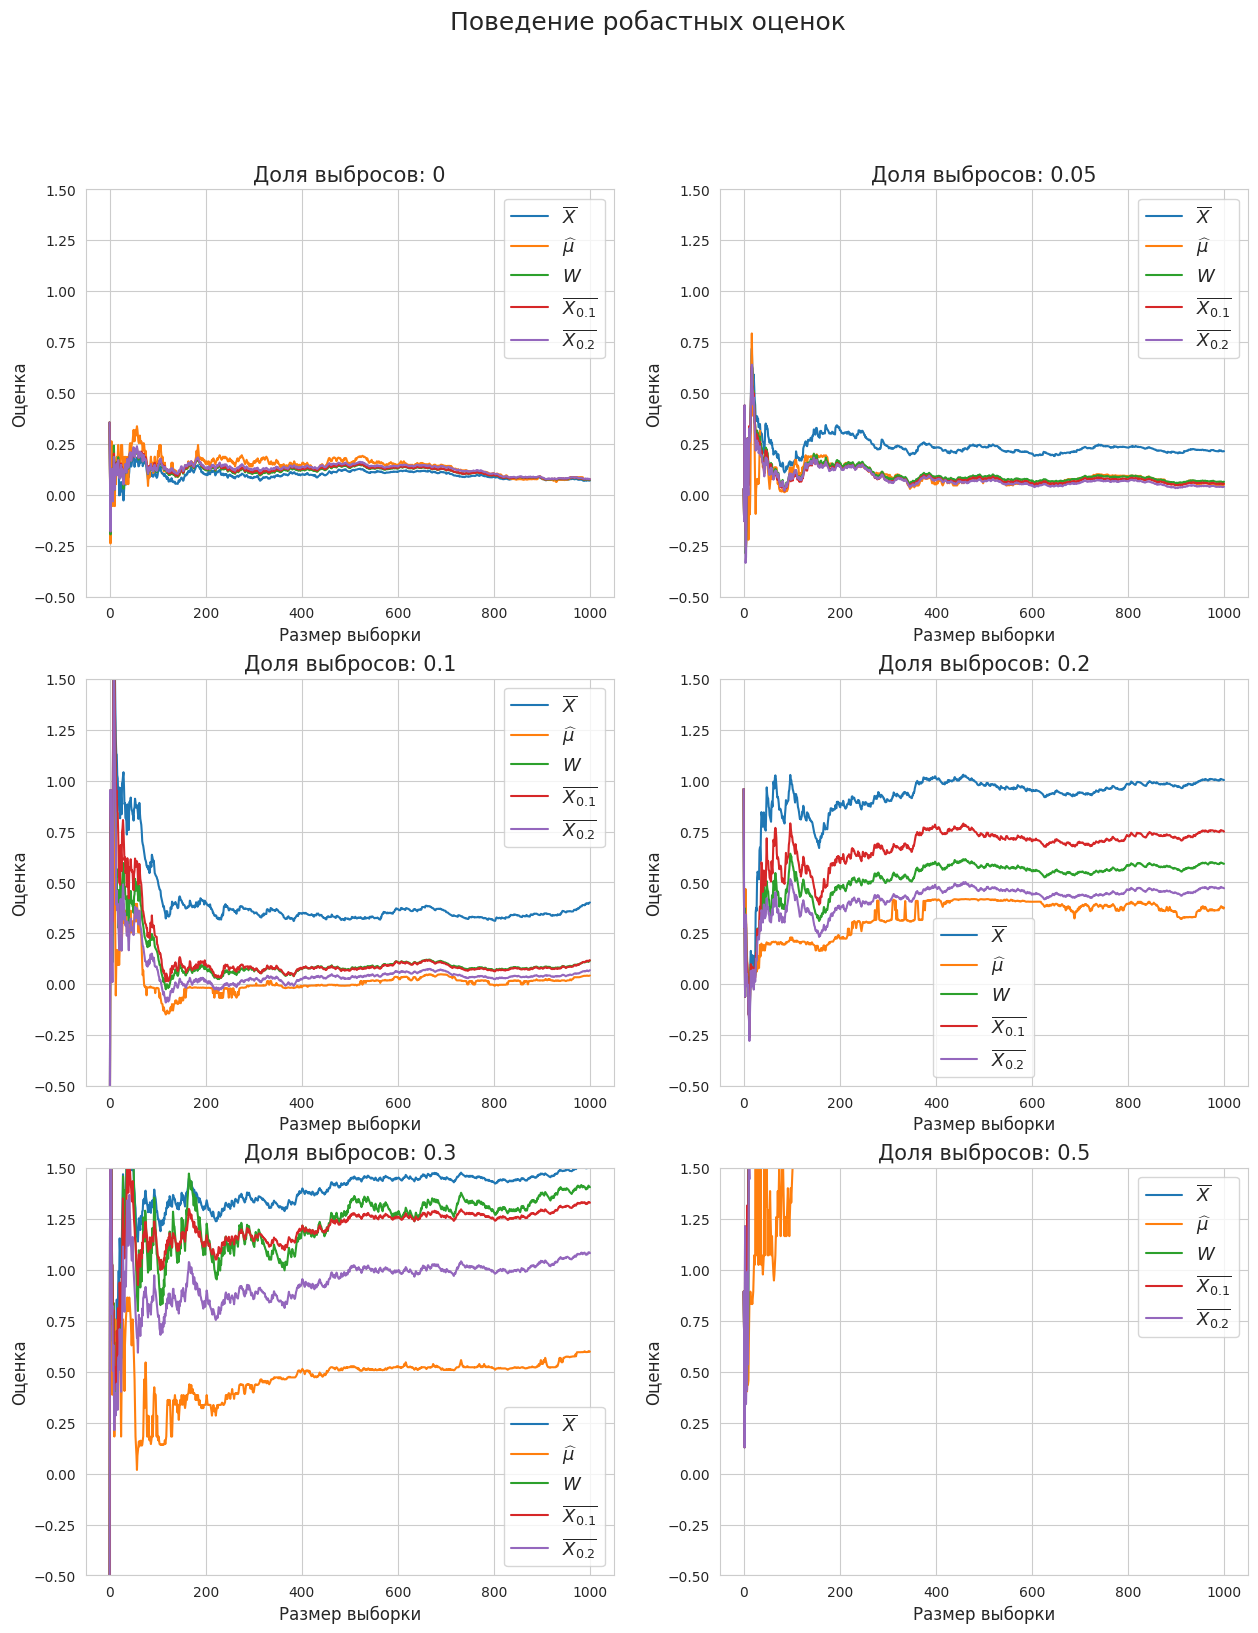

In [42]:
fractions = [0, 0.05, 0.1, 0.2, 0.3, 0.5]
sample_size = 1000

sns.set_style("whitegrid")
_, axes = plt.subplots(
    len(fractions) // 2, 2,
    figsize=(15, 18)
)
plt.suptitle("Поведение робастных оценок", fontsize=18)

for i, fraction in enumerate(fractions):
    n_outliers = int(sample_size * fraction)
    n_inliers = sample_size - n_outliers
    inliers = np.random.normal(0, 1, n_inliers)
    outliers = np.random.normal(5, 1, n_outliers)
    sample = np.hstack((inliers, outliers))
    np.random.shuffle(sample)
    ax = axes[i // 2, i % 2]
    compare_robust_estimations(sample, ax)
    ax.set_title(f"Доля выбросов: {fraction}", fontsize=15)

**Вывод:** Представленные графики показывают, что с увеличением доли выбросов в данных методы оценивания ведут себя по-разному. Среднее значение выборки ($\overline{X}$) оказывается наиболее подверженным влиянию выбросов, особенно при их высоких долях, что приводит к значительным отклонениям. Напротив, методы, такие как $\tilde{\mu}$ и $W$, демонстрируют большую устойчивость к выбросам и обеспечивают более стабильные результаты даже при увеличении размера выборки. Это указывает на то, что для данных с выбросами предпочтительнее использовать более устойчивые методы, такие как $\tilde{\mu}$ и $W$, поскольку они дают более точные оценки в условиях загрязнённых данных.

### Изменение асимптотической дисперсии усечённого среднего

Посчитаем теперь для модели $\mathcal{N}(\theta, 1)$ асимпотическую дисперсию усечённого среднего порядка $\alpha$ исходя из разобранной теоремы. Также посмотрим на верхнюю оценку.

$$ \sigma_\alpha^2 = \frac{2}{(1 - 2\alpha)^2} \left( \int\limits_0^{u_{1 - \alpha}} x^2 p(x) dx + \alpha u_{1 - \alpha}^2 \right) $$

Чтобы посчитать верхнюю оценку, воспользуемся неравенством из теоремы:

$$\frac{DX_1}{\sigma_\alpha^2} \geqslant (1 - 2 \alpha)^2$$

$$ \sigma_\alpha^2 \leqslant \frac{DX_1}{(1 - 2 \alpha)^2} $$

In [43]:
def calc_sigma_sq(alpha):
    """Вычисляет дисперсию усечённого среднего для N(theta, 1)"""
    quantile = sps.norm.ppf(1 - alpha)
    func_to_int = lambda x: x ** 2 * sps.norm.pdf(x)
    integral = scipy.integrate.quad(func_to_int, 0, quantile)[0]
    sigma_sq = 2 / (1 - 2 * alpha) ** 2 * (integral + alpha * quantile ** 2)
    return sigma_sq

Построим график дисперсии для $\alpha \in (0, 0.5)$

Посчитайте верхнюю оценку дисперсии по формуле выше.

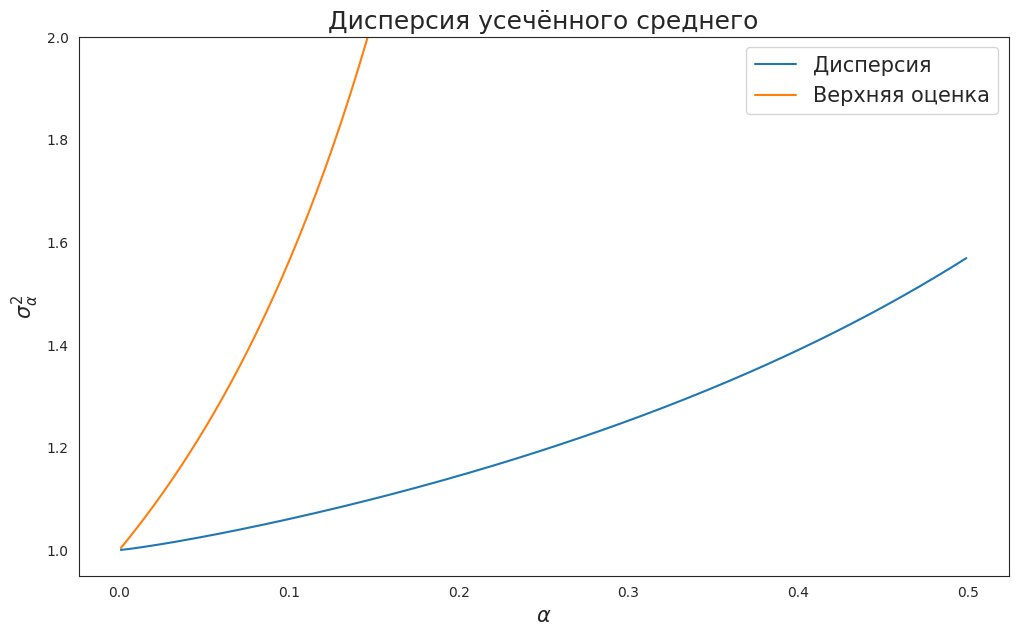

In [45]:
sns.set_style("white")
plt.figure(figsize=(12, 7))
eps = 0.001
grid = np.linspace(eps, 0.5 - eps, 200)
sigmas = [calc_sigma_sq(alpha) for alpha in grid]
estim = 1 / (1 - 2 * grid) ** 2

plt.plot(grid, sigmas, label="Дисперсия")
plt.plot(grid, estim, label="Верхняя оценка")

plt.title("Дисперсия усечённого среднего", fontsize=18)
plt.xlabel(r"$\alpha$", fontsize=15)
plt.ylabel(r"$\sigma_\alpha^2$", fontsize=15)
plt.legend(fontsize=15)
plt.ylim(0.95, 2)
plt.show()

**Вопрос:** Какой оценке соответствует крайняя справа точка на графике?

Крайняя правая точка на графике соответствует оценке медианы. Когда параметр усечения $\alpha$ стремится к 0.5, усечённое среднее порядка $\alpha$ превращается в медиану выборки. Это происходит потому, что при $\alpha = 0.5$ усечённое среднее исключает все данные, кроме центральных элементов.

На графике это видно в резком увеличении дисперсии усечённого среднего по мере приближения $\alpha$ к 0.5, поскольку количество данных, участвующих в оценке, уменьшается. При $\alpha = 0.5$ дисперсия становится очень большой, что отражает неопределённость медианы при малом объёме данных.

Таким образом, крайняя правая точка на графике иллюстрирует поведение дисперсии медианы как оценки центральной тенденции при максимальном усечении данных.
